# Introduzione 

Una delle equazioni fondamentali dell'Elettrostatica è sicuramente l'equazione di Poisson:

$$

\nabla^2 V = - \frac{\rho}{\varepsilon_0}

$$

Che, nel caso statico, lega la prima e la terza equazione di Maxwell. 

Se nei problemi elettrostatici comparissero sempre distribuzioni localizzate di carica, discrete o continue, senza superfici di confine, la soluzione generale 

$$

V = \frac{1}{4 \pi \varepsilon_0} \int_{\tau} \frac{\rho(r)}{r} \ d\tau \quad (1.1) 

$$

sarebbe quella più diretta e più conveniente per ogni problema. Non ci sarebbe alcun bisogno delle equazioni di Poisson o di Laplace. 

Nella realtà, molti, se non la maggior parte, dei problemi dell’elettrostatica sono formulati in regioni finite di spazio contenenti o meno delle cariche, e con delle condizioni al contorno assegnate sulle superfici di confine. Quindi la (1.1) non è più così utile se non in casi semplici.

Supponiamo di essere in un regione di spazio limitata, è possibile dimostrare che la specificazione al bordo del potenziale (condizione al contorno di Dirichlet) o della sua derivata normale (condizione al contorno di Neumann), definisce univocamente il problema del potenziale.

Se volessimo risolvere l'equazione di Poisson analiticamente dovremmo sfruttare la seconda identità di Green (in modo da legare le condizioni al contorno e i valori del potenziale all'interno della regione di interesse) e trovare una particolare funzione di Green che permetta di esplicitare il potenziale. Nonostante ciò, *spesso è piuttosto complicato, se non impossibile, determinare la funzione di Green più adatta*

Per questo sono stati sviluppati dei metodi per risolvere i problemi di elettrostatica riguardanti le condizioni al bordo, come:

1. **Metodo delle cariche immagine**, lontano dal metodo usuale di trovare la funzione di Green ma utile solo quando si trattano regioni di spazio con geometrie particolarmente favorevoli (come piani infiniti o sfere)

2. **Metodo di separazione delle variabili**, approccio analitico, ma anche questo utile solo quando il dominio ha geometrie particolari

3. **Analisi agli elementi finiti (FEM - finite element method)**, approccio computazionale e generale, posto delle condizioni al contorno può essere applicato a qualunque geometria.

In questo progetto ho sviluppato un codice che crea un dominio *casuale* $\Omega \sub \mathbb{R}^2$ con condizioni al contorno di Dirichlet *casuali* e, sfruttando il FEM, trova il potenziale in qualsiasi punto del dominio. 

>### Nota 
>
>Prima di proseguire si consiglia caldamente di guardare la parte di teoria dove ho riportato le parti essenziali del *finite element method* che sono state necessarie per fare il progetto.
> 

---

# FEM per la risoluzione dell'equazione di Poisson

Iniziamo con la creazione di un dominio casuale $\Omega \sub \mathbb{R}^2$ semplicemente connesso. Per far questo sfruttiamo un algoritmo simile a quello del *random walk*. 

E\' importante sottolineare che ho aggiunto un seed per rendere i risultati riproducibili (per vedere il caso generale basta commentare la riga contenente `np.random.seed()`)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.tri as mtri
import pygmsh

# ------- Consideriamo un dominio Ω e troviamo una soluzione dell'equazione di Poisson poste le condizioni al contorno di Dirichlet ---------

np.random.seed(42)  # seed per riproducibilità dei risultati

# Dominio casuale semplicemente connesso (fatto sulla stile random walk)
n_modi = 5
R0 = 1.0
a_modi = np.random.uniform(-0.2, 0.2, n_modi)
phi_modi = np.random.uniform(0, 2*np.pi, n_modi)

theta = np.linspace(0, 2*np.pi, 100, endpoint=False)
raggio = R0 + sum(a_modi[k] * np.cos((k+1)*theta + phi_modi[k]) for k in range(n_modi))
vertici = np.column_stack([raggio*np.cos(theta), raggio*np.sin(theta)])

Adesso creiamo delle condizioni al contorno di Dirichlet casuali sfruttando la funzione `np.random.uniform()` e scegliendo una generica funzione $g_D$.

In [2]:
# Condizioni al bordo casuali 
cA, cB, cC, cD, cE = np.random.uniform(-1, 1, 5)

def g_D(x, y):
    return cA*x + cB*y + cC*np.cos(np.pi*x) + cD*np.sin(np.pi*y) + cE*np.exp(x*y) # formula a caso

Supponiamo di posizionare nei punti $(x_1, y_1)$ e $(x_2, y_2)$ due cariche, una positiva e una negativa, di valore unitario. Come densità di carica dovremmo avere una somma di due delta di Dirac, del tipo 

$$

\rho(x,y) = Q\delta(x - x_1)\delta(y - y_1) - Q\delta(x - x_2)\delta(y - y_2) 

$$

Tuttavia la delta di Dirac non è una vera funzione, è una distribuzione. Per usarla numericamente bisogna regolarizzarla con una funzione vera e la scelta più naturale è una gaussiana normalizzata "piccata". 

Quindi possiamo approssimare la delta delta come

$$

\delta(x - x_0)\delta(y - y_0) = \frac{1}{2 \pi \sigma^2} \text{exp}\left( - \frac{(x - x_0)^2 + (y - y_0)^2}{2 \sigma^2} \right)

$$

Affinché questa sia "piccata" dobbiamo considerare $\sigma \to 0$. 

In questo modo la distribuzione diventa 

$$

\rho(x,y) = \frac{Q}{2 \pi \sigma^2} \left[\text{exp}\left( - \frac{(x - x_1)^2 + (y - y_1)^2}{2 \sigma^2}  \right) - \text{exp}\left( - \frac{(x - x_2)^2 + (y - y_2)^2}{2 \sigma^2}  \right) \right]

$$

In [ ]:
# Densità di carica
def rho(x, y):
    sigma = 0.05
    x1, y1 = -0.3, 0.0 # carica positiva
    x2, y2 =  0.3, 0.0 # carica negativa
    Q = 1.0
    g1 = np.exp(-((x-x1)**2 + (y-y1)**2) / (2*sigma**2))
    g2 = np.exp(-((x-x2)**2 + (y-y2)**2) / (2*sigma**2))
    return Q / (2*np.pi*sigma**2) * (g1 - g2)

Il passo fondamentale nel FEM è la suddivisione del dominio in triangoli $K_i$ (processo che prende il nome di mesh). Negli ultimi anni sono stati sviluppati molti algoritmi per automatizzare la generazione del mesh di un certo dominio: tra questi c'è l'algoritmo di Delaunay, che, dato un set di punti (che rappresentano il bordo), può generare un mesh in cui questi punti sono dei nodi.

La libreria `pygmsh` (interfaccia Python al *mesh generator* Gmsh) costruisce, per default su domini piani, una triangolazione di Delaunay: a partire dalla triangolazione di Delaunay dei vertici al bordo, l'algoritmo inserisce iterativamente punti nei circocentri dei triangoli più grandi finché il vincolo sulla dimensione massima `mesh-size` non è soddisfatto.

In [4]:
# Generazione della mesh
with pygmsh.geo.Geometry() as geom:
    geom.add_polygon(vertici.tolist(), mesh_size=0.05)
    mesh = geom.generate_mesh()

P = mesh.points[:, :2] # matrice dei punti 
T = mesh.cells_dict["triangle"] # matrice di connettività
Trasp_T = mesh.cells_dict["triangle"].T
Trasp_P = mesh.points[:, :2].T
n_p = np.size(Trasp_P[1]) # numero nodi
n_t = np.size(Trasp_T[1]) # numero triangoli

# Array dell'area dei triangoli 

K = np.zeros(n_t)
for i in range(n_t):
    r, s, t = T[i]
    K_i = 0.5 * abs(P[r][0]*(P[s][1] - P[t][1]) + P[s][0]*(P[t][1] - P[r][1]) + P[t][0]*(P[r][1] - P[s][1])) # area del triangolo K_i
    K[i] =  K_i

A questo punto non resta che ricavare la matrice di rigidezza e il vettore dei carichi, necessarie per risolvere il sistema finale.

Iniziamo trovando la matrice di rigidezza:

Per prima cosa troviamo la matrice di rigidezza locale, 

$$

\tilde{A}^K = \begin{pmatrix}
b_1^2 + c_1^2 & b_1 b_2 + c_1 c_2 & b_1 b_3 + c_1 c_3 \\
b_2 b_1 + c_2 c_1 & b_2^2 + c_2^2 & b_2 b_3 + c_2 c_3 \\
b_3 b_1 + c_3 c_1 & b_3 b_2 + c_3 c_2 & b_3^2 + c_3^2
\end{pmatrix} |K|

$$

che ci permette, tramite la mappatura $\{ 1, 2, 3 \} \to \{ r, s, t \}$ (dove $r, s, t$ sono i valori della $j$-esima colonna della matrice $T$) di ottenere la matrice di rigidezza globale $A^K$ 

In [5]:
# Troviamo la matrice A 

A_stiff = np.zeros((n_p, n_p))

for i in range(n_t):
    r, s, t = T[i]
    nodi = [r, s, t]

    # Coefficienti delle hat functions locali
    b_coef = np.array([P[s,1] - P[t,1],
                       P[t,1] - P[r,1],
                       P[r,1] - P[s,1]]) / (2 * K[i])
    c_coef = np.array([P[t,0] - P[s,0],
                       P[r,0] - P[t,0],
                       P[s,0] - P[r,0]]) / (2 * K[i])

    # Matrice di rigidezza locale \tilde{A}^K
    A_loc = (np.outer(b_coef, b_coef) + np.outer(c_coef, c_coef)) * K[i]

    # Assemblaggio: accumulo direttamente sulle entrate globali
    for j in range(3):
        for k in range(3):
            A_stiff[nodi[j], nodi[k]] += A_loc[j, k]


Per il vettore dei carichi approssimando con la regola del vertice:

$$

b_j^{K_i} \approx \frac{1}{3} f(N_j) \, |K| \qquad j = 1, 2, 3

$$

In [6]:
# Troviamo il vettore b
b_vec = np.zeros(n_p)

for i in range(n_t):
    nodi = T[i]
    for j in range(3):
        N_j = P[nodi[j]]
        b_vec[nodi[j]] += rho(N_j[0], N_j[1]) * K[i] / 3

A questo punto, per imporre le condizioni al contorno, dobbiamo distinguere i nodi che giacciono su $\partial \Omega$ da quelli interni. La libreria `pygmsh` rende facile questa operazione, perché oltre alla matrice di connettività dei triangoli mantiene anche una lista degli **spigoli del bordo**, accessibile tramite `mesh.cells_dict["line"]`: si tratta di una matrice $n_e \times 2$ in cui ogni riga contiene gli indici dei due nodi che formano uno spigolo di $\partial \Omega$.

Per ricavare l'insieme $I_b$ dei nodi di bordo basta quindi prendere gli indici contenuti in questa matrice, rimuovendo i duplicati (un nodo di bordo appartiene tipicamente a due spigoli consecutivi). I nodi interni $I_{int}$ si ottengono per complemento, come differenza insiemistica tra $\{0, 1, \dots, n_p - 1\}$ e $I_b$.

In [7]:
# Identificazione dei nodi di bordo
spigoli_bordo = mesh.cells_dict["line"]
I_b   = np.unique(spigoli_bordo)
I_int = np.setdiff1d(np.arange(n_p), I_b)

Questa divisione ci permette di estrarre dalla matrice di rigidezza e dal vettore dei carichi le settomatrici $A_{00}$ e $A_{0g}$ e i vettori estratti $b_0$ e $\xi_g$ necessari per andare a risolvere il sistema ridotto 

$$

A_{00} \xi_0 = b_0 - A_{0g} \xi_g

$$

In [8]:
# Partizione del sistema
A_00 = A_stiff[np.ix_(I_int, I_int)] # blocco interno-interno
A_0g = A_stiff[np.ix_(I_int, I_b)] # blocco interno-bordo
b_0  = b_vec[I_int]

A questo punto possiamo andare a risolvere il sistema avendo imposto le condizioni al bordo 

In [9]:
# Valori al bordo (g_D valutata sui nodi di bordo della mesh)
xi_g = g_D(P[I_b, 0], P[I_b, 1])

# Risoluzione del sistema ridotto
u_int = np.linalg.solve(A_00, b_0 - np.dot(A_0g, xi_g))

# Ricostruzione della soluzione globale
u_h = np.zeros(n_p)
u_h[I_int] = u_int
u_h[I_b] = xi_g

Mostrando esplicitamente i risultati si ha 

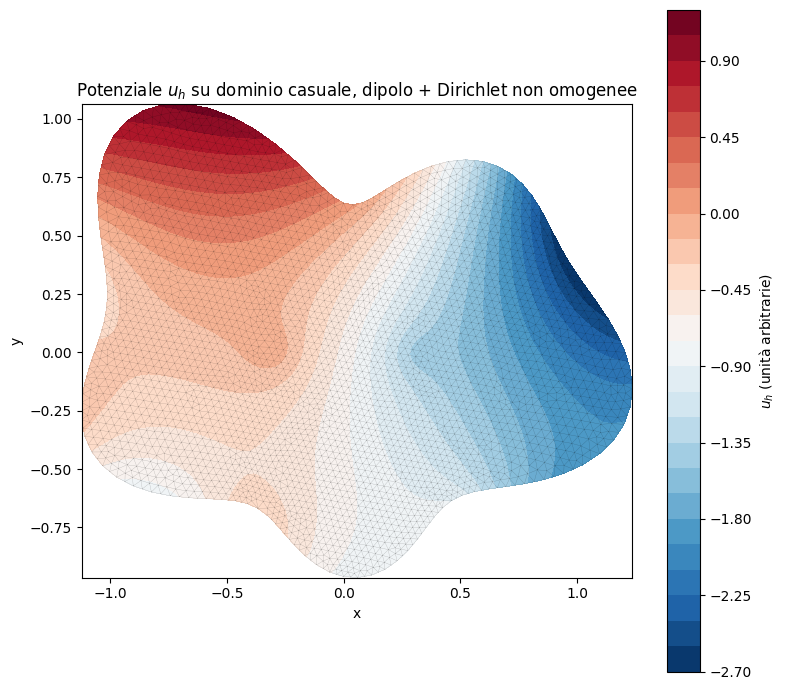

In [10]:
# ------- Plot dei risultati -------
triang = mtri.Triangulation(P[:, 0], P[:, 1], T)

fig, ax = plt.subplots(figsize=(8, 7))
cs = ax.tricontourf(triang, u_h, levels=30, cmap="RdBu_r")
ax.triplot(triang, lw=0.2, color="k", alpha=0.3)
ax.set_aspect("equal")
ax.set_title(r"Potenziale $u_h$ su dominio casuale, dipolo + Dirichlet non omogenee")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(cs, ax=ax, label=r"$u_h$ (unità arbitrarie)")
plt.tight_layout()
plt.show()

Il plot mostra il potenziale $u_h$​ all'interno del dominio. Si distinguono chiaramente le due zone di concentrazione: una positiva (rossa) attorno a $(−0,3,0)$ e una negativa (blu) attorno a $(0,3,0)$. 
Le condizioni al bordo non omogenee si manifestano come una distorsione asimmetrica del campo verso il bordo del dominio, particolarmente visibile nelle zone lontane dalle cariche, dove il potenziale è dominato da $g_D$​ piuttosto che da $\rho$.